### 경로 설정
실행 환경에 맞게 수정

In [1]:
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Colab Notebooks/2025-2 빅데이터알고리즘'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


라이브러리 임포트 및 파일 불러오기

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE


movies = pd.read_csv(os.path.join(base_path, 'movies.csv'))
ratings = pd.read_csv(os.path.join(base_path, 'ratings.csv'))
tags = pd.read_csv(os.path.join(base_path, 'tags.csv'))
links = pd.read_csv(os.path.join(base_path, 'links.csv'))

# 타임스탬프 변환 (ratings와 tags의 timestamp는 초 단위이므로 datetime으로 변환)
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
tags['timestamp'] = pd.to_datetime(tags['timestamp'], unit='s')

movies.head(), ratings.head(), tags.head(), links.head()

(   movieId                               title  \
 0        1                    Toy Story (1995)   
 1        2                      Jumanji (1995)   
 2        3             Grumpier Old Men (1995)   
 3        4            Waiting to Exhale (1995)   
 4        5  Father of the Bride Part II (1995)   
 
                                         genres  
 0  Adventure|Animation|Children|Comedy|Fantasy  
 1                   Adventure|Children|Fantasy  
 2                               Comedy|Romance  
 3                         Comedy|Drama|Romance  
 4                                       Comedy  ,
    userId  movieId  rating           timestamp
 0       1        1     4.0 2000-07-30 18:45:03
 1       1        3     4.0 2000-07-30 18:20:47
 2       1        6     4.0 2000-07-30 18:37:04
 3       1       47     5.0 2000-07-30 19:03:35
 4       1       50     5.0 2000-07-30 18:48:51,
    userId  movieId              tag           timestamp
 0       2    60756            funny 2015-10-

# EDA ver1

## (1) 사용자 클러스터링 (취향이 비슷한 유저 그룹 찾기)

/tmp/ipython-input-1943206150.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  user_stats['std_rating'].fillna(0, inplace=True)


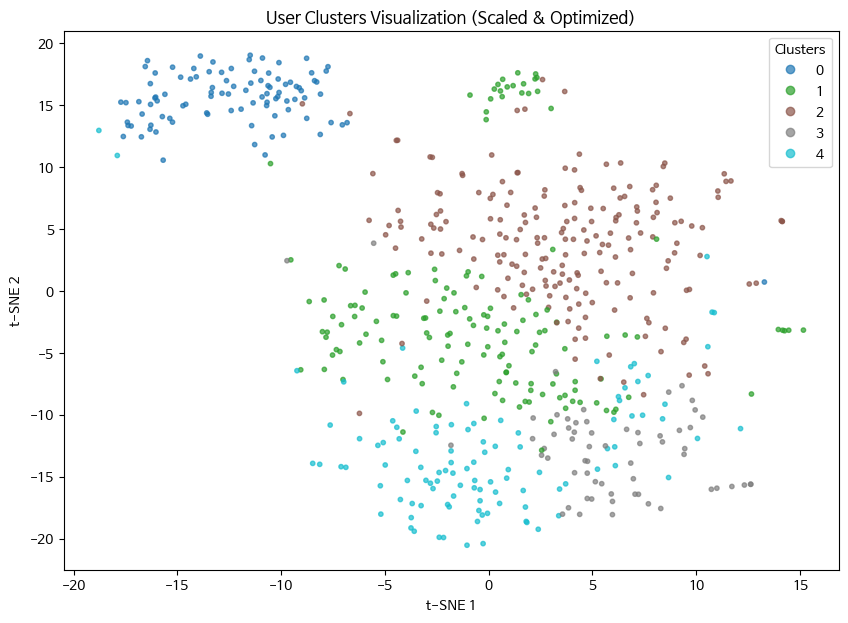

Cluster Sizes:
cluster
2    197
1    150
4    106
0     96
3     61
Name: count, dtype: int64
         avg_rating    Action     Drama  Thriller  std_rating
cluster                                                      
0          3.564252  0.345867  0.421086  0.369865    0.904695
1          3.613022  0.415629  0.356942  0.312903    0.948530
2          3.566990  0.207331  0.445960  0.202758    0.976687
3          3.914870  0.449176  0.375059  0.238145    0.788400
4          3.823398  0.298996  0.527638  0.313854    0.904816


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 1. 기초 통계 (Rating Stats)
# std_rating의 결측치는 0으로 채움 (평가 1개인 경우)
user_stats = ratings.groupby('userId')['rating'].agg(['mean', 'std']).reset_index()
user_stats.columns = ['userId', 'avg_rating', 'std_rating']
user_stats['std_rating'].fillna(0, inplace=True)

# 2. 장르 선호도 (Genre Ratio)
# 유저가 본 영화 중 해당 장르가 차지하는 비율 (0~1 사이 값)
genre_dummies = movies['genres'].str.get_dummies(sep='|')
movie_genre = pd.concat([movies[['movieId']], genre_dummies], axis=1)

merged = ratings.merge(movie_genre, on='movieId')
# rating 컬럼 제외하고 장르 컬럼만 선택하여 평균
genre_cols = genre_dummies.columns
user_genre_pref = merged.groupby('userId')[genre_cols].mean().reset_index()

# 3. 태그 TF-IDF (Tag Content)
# [최적화] 영화별로 태그를 먼저 합침 (Document = Movie)
valid_tags = tags.dropna(subset=['tag'])
movie_tags_str = valid_tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x.astype(str))).reset_index()

tfidf = TfidfVectorizer(max_features=300, stop_words='english') # 불용어 제거 추가
movie_tfidf_matrix = tfidf.fit_transform(movie_tags_str['tag'])

# 영화별 TF-IDF DataFrame 생성
movie_tag_df = pd.DataFrame(movie_tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
movie_tag_df['movieId'] = movie_tags_str['movieId'].values

# 유저가 본 영화들의 태그 벡터 평균 계산
# movieId, rating 등 불필요한 컬럼이 섞이지 않도록 merge 후 컬럼 필터링 주의
user_tag_merged = ratings[['userId', 'movieId']].merge(movie_tag_df, on='movieId')
user_tag_pref = user_tag_merged.drop(columns=['movieId']).groupby('userId').mean().reset_index()

# 4. 벡터 병합
user_vector = user_stats.merge(user_genre_pref, on='userId', how='left')
user_vector = user_vector.merge(user_tag_pref, on='userId', how='left')
user_vector.fillna(0, inplace=True) # 태그/장르 정보 없는 유저 0 처리

# 5. 스케일링 (Scaling)
# userId 제외하고 값만 추출
X = user_vector.drop(columns=['userId']).values

# Feature 간 스케일 차이를 맞춤
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. 차원 축소 및 클러스터링
# 고차원 → SVD (30차원)
svd = TruncatedSVD(n_components=30, random_state=42)
user_lowdim = svd.fit_transform(X_scaled)

# KMeans 클러스터링
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(user_lowdim)
user_vector['cluster'] = clusters

# 7. 시각화 (t-SNE)
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
emb = tsne.fit_transform(user_lowdim)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(emb[:,0], emb[:,1], c=user_vector['cluster'], s=10, cmap='tab10', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.title("User Clusters Visualization (Scaled & Optimized)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

print("Cluster Sizes:")
print(user_vector['cluster'].value_counts())

# 클러스터별 평균 특성 비교
cluster_analysis = user_vector.groupby('cluster')[['avg_rating', 'Action', 'Drama', 'Thriller', 'std_rating']].mean()
print(cluster_analysis)

평점 정규화(Normalization)의 필요성 입증:
Cluster 3(평균 3.91) 유저와 Cluster 0(평균 3.56) 유저가 똑같이 4점을 줬을 때, 그 의미는 다름

Cluster 0의 4점은 "정말 명작"이라는 뜻이고, Cluster 3의 4점은 "볼만했다"는 뜻일 수 있음
→ Mean-Centering(User Bias 제거) 실험이 왜 필수적인지 보여주는 근거

## (2) 장르 조합(멀티 장르)의 패턴 분석

/tmp/ipython-input-3204507634.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=genre_freq.index, x=genre_freq.values, palette='viridis')


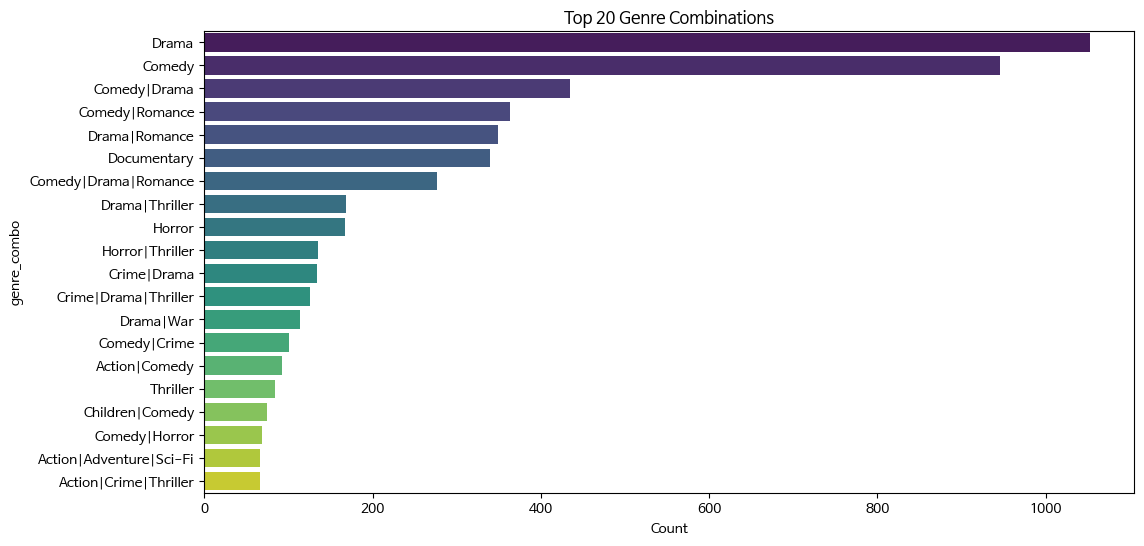

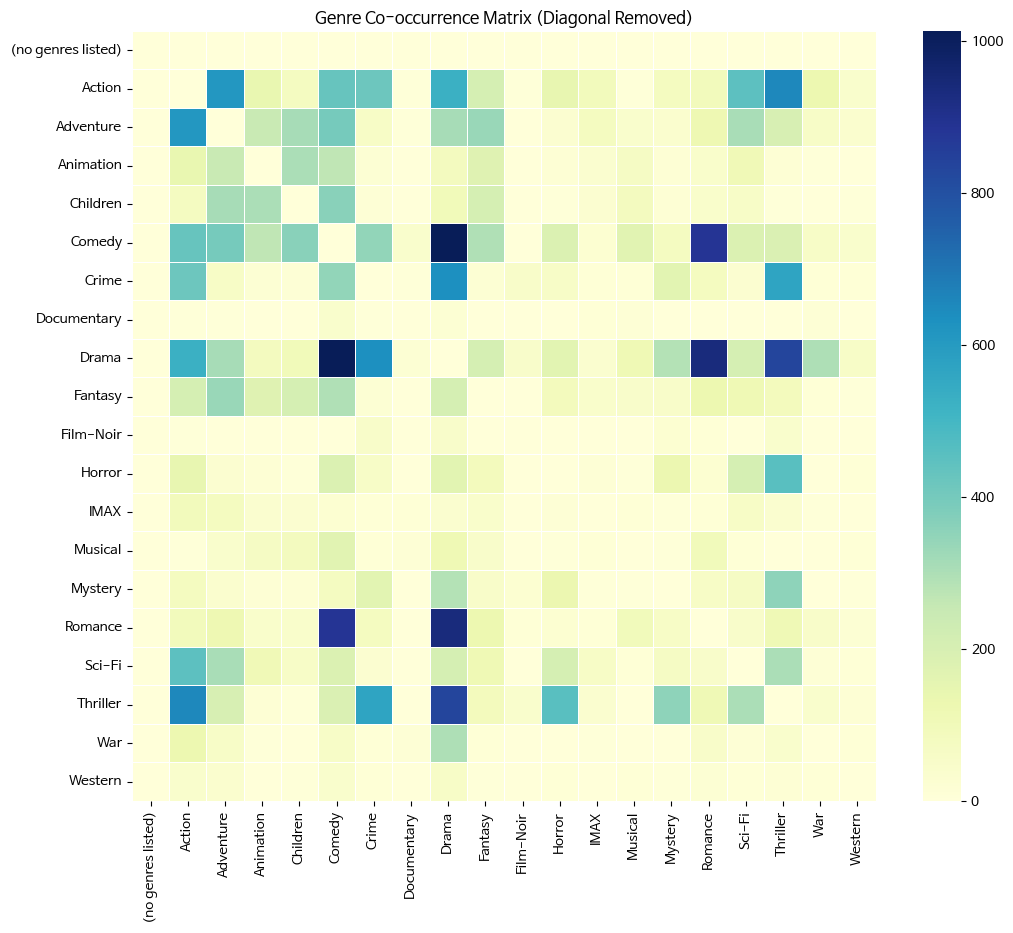

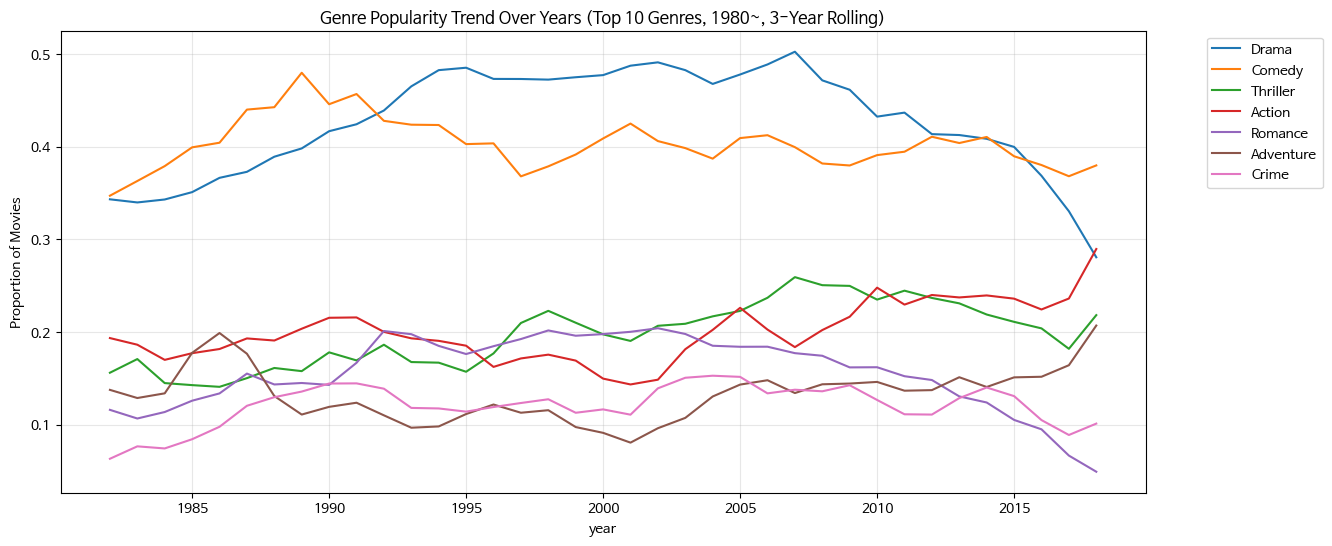

In [10]:
# 1. 장르 조합 빈도
movies['genre_combo'] = movies['genres']
genre_freq = movies['genre_combo'].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(y=genre_freq.index, x=genre_freq.values, palette='viridis')
plt.title("Top 20 Genre Combinations")
plt.xlabel("Count")
plt.show()


# 2. 장르 Co-occurrence Matrix
genre_matrix = genre_dummies.T.dot(genre_dummies)

# 대각선(자기 자신)은 값이 너무 커서 다른 관계를 가리므로 0으로 처리
np.fill_diagonal(genre_matrix.values, 0)

plt.figure(figsize=(12, 10))
sns.heatmap(genre_matrix, cmap='YlGnBu', linewidths=.5)
plt.title("Genre Co-occurrence Matrix (Diagonal Removed)")
plt.show()

# 3. 연도별 장르 트렌드
# 연도 추출 (결측치 제거)
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)
movies = movies.dropna(subset=['year']) # 연도 없는 데이터 제거

# 연도별 장르 비율 계산
# concat을 사용하여 인덱스 불일치 방지
genre_year_df = pd.concat([movies[['year']], genre_dummies], axis=1)
year_trend = genre_year_df.groupby('year').mean()

# 여기서는 1980년 이후 데이터만 확인
year_trend = year_trend[year_trend.index >= 1980]

# 상위 7개 인기 장르만 선정
top_genres = genre_dummies.sum().sort_values(ascending=False).head(7).index
year_trend_top = year_trend[top_genres]

# 3년 윈도우 적용
year_trend_smooth = year_trend_top.rolling(window=3).mean()

plt.figure(figsize=(14, 6))
sns.lineplot(data=year_trend_smooth, dashes=False)
plt.title("Genre Popularity Trend Over Years (Top 10 Genres, 1980~, 3-Year Rolling)")
plt.ylabel("Proportion of Movies")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

- 연도별 장르를 점수 평균으로 내기
-

## (3) 태그를 활용한 내용 기반(content-based) 추천용 피처 엔지니어링

Matrix Shape: (1572, 252)


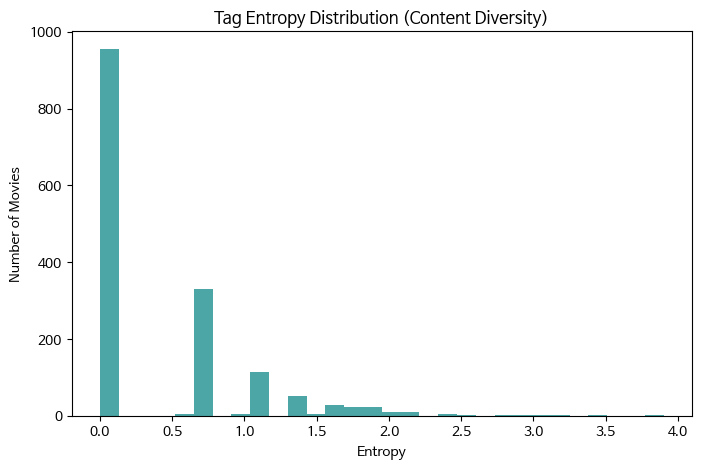

Similarity Matrix Calculated: (1572, 1572)


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import entropy

# 1. 영화별로 태그 합치기
tag_data = tags.dropna(subset=['tag'])
tag_data['tag'] = tag_data['tag'].astype(str)
movie_tags = tag_data.groupby('movieId')['tag'].apply(lambda x: ' '.join(x)).reset_index()

# 2. TF-IDF Vectorization
# min_df=5: 최소 5개 영화에 등장한 태그만 사용 (노이즈 제거)
tfidf = TfidfVectorizer(max_df=0.9, min_df=5, stop_words='english')
movie_tag_tfidf = tfidf.fit_transform(movie_tags['tag'])

print(f"Matrix Shape: {movie_tag_tfidf.shape}")

# 3. 태그 다양성 지표 (Entropy)
# Sparse Matrix 상태에서 바로 계산하여 메모리 절약
def sparse_entropy(matrix):
    # 각 행(영화)의 합이 1이 되도록 정규화
    # TF-IDF 값 자체를 확률로 간주
    row_sums = np.array(matrix.sum(axis=1))

    # 0으로 나누기 방지
    row_sums[row_sums == 0] = 1
    probs = matrix / row_sums

    # Entropy 계산: -sum(p * log(p))
    # sparse matrix 연산 효율을 위해 data 속성 직접 조작
    probs.data = probs.data * np.log(probs.data)
    return -np.array(probs.sum(axis=1)).flatten()

tag_entropy = sparse_entropy(movie_tag_tfidf)

plt.figure(figsize=(8, 5))
plt.hist(tag_entropy, bins=30, color='teal', alpha=0.7)
plt.title("Tag Entropy Distribution (Content Diversity)")
plt.xlabel("Entropy")
plt.ylabel("Number of Movies")
plt.show()

# 4. 태그 기반 영화 유사도 (Cosine Similarity)
sim_tag = cosine_similarity(movie_tag_tfidf)
print("Similarity Matrix Calculated:", sim_tag.shape)

## (4) 평점 시계열을 활용한 유저/영화의 트렌드 분석

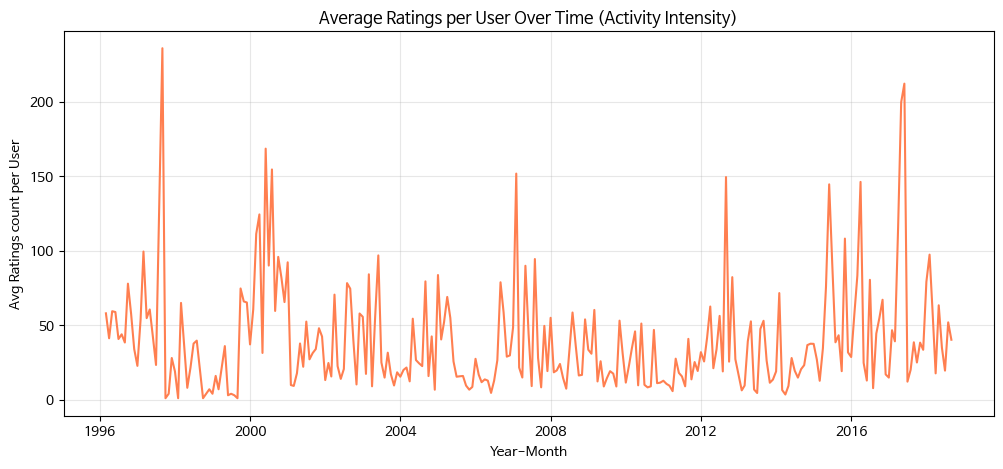

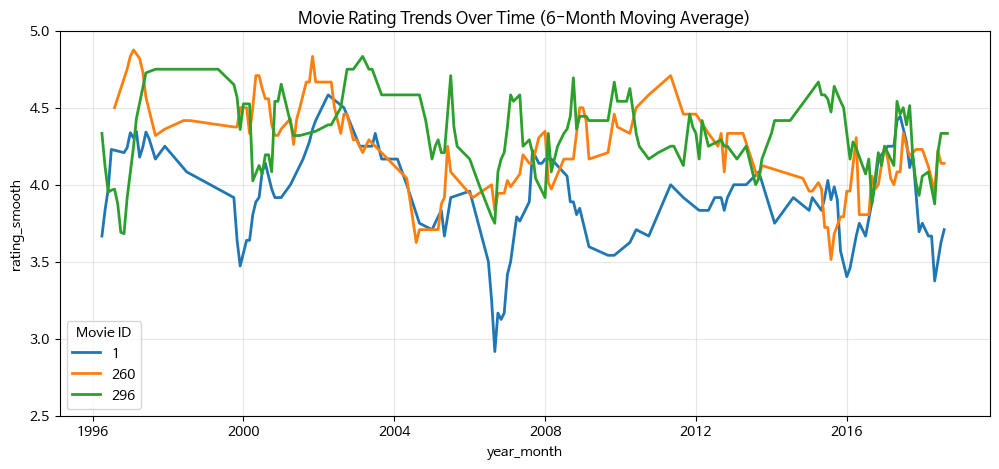

In [12]:
# 1. Timestamp 변환
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
# 시각화를 위해 Period 대신 datetime의 1일자로 맞춤
ratings['year_month'] = ratings['datetime'].dt.to_period('M').dt.to_timestamp()

# 2. 유저 활동량 변화
# 월별 전체 평점 개수 / 월별 활성 유저 수 = 인당 평균 활동량
monthly_stats = ratings.groupby('year_month').agg(
    total_ratings=('rating', 'count'),
    active_users=('userId', 'nunique')
).reset_index()

monthly_stats['ratings_per_user'] = monthly_stats['total_ratings'] / monthly_stats['active_users']

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_stats, x='year_month', y='ratings_per_user', color='coral')
plt.title("Average Ratings per User Over Time (Activity Intensity)")
plt.ylabel("Avg Ratings count per User")
plt.xlabel("Year-Month")
plt.grid(True, alpha=0.3)
plt.show()

# 3. 영화 평점 시계열 (개별 영화 트렌드)
# 데이터 집계
movie_trend = ratings.groupby(['movieId', 'year_month'])['rating'].mean().reset_index()

# 보고 싶은 영화 ID 지정 (예: 토이스토리(1), 스타워즈(260), 펄프픽션(296))
target_movies = [1, 260, 296]
sample = movie_trend[movie_trend['movieId'].isin(target_movies)].copy()

# hue 구분을 위해 문자열로 변환
sample['movieId_str'] = sample['movieId'].astype(str)

# 이동 평균(Rolling)으로 노이즈 제거 (Window=6개월)
sample['rating_smooth'] = sample.groupby('movieId_str')['rating'].transform(lambda x: x.rolling(window=6, min_periods=1).mean())

plt.figure(figsize=(12, 5))
sns.lineplot(data=sample, x='year_month', y='rating_smooth', hue='movieId_str', palette='tab10', linewidth=2)
plt.title("Movie Rating Trends Over Time (6-Month Moving Average)")
plt.ylim(2.5, 5.0) # 평점 범위 고정
plt.legend(title="Movie ID")
plt.grid(True, alpha=0.3)
plt.show()

연도별 -> 월별 raitng으로 확장
- rating 추세 보기 (예전에는 짜게 줬는데 지금은 후하게 줌)

## (5) 리메이크 영화 확인

폰트 설정 (skip 가능)
- 이 셀을 실행 후 세션 다시 시작
- 현재 노트북의 1,2번째 셀 실행

In [ ]:
# 1. 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt

# 2. 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 3. 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (10.8 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and direc

총 영화 수: 9742
제목이 동일한(리메이크/중복) 영화 수: 536

[리메이크 예시 데이터]
      movieId                   clean_title    year  \
905      1203                  12 Angry Men  1957.0   
7332    77846                  12 Angry Men  1997.0   
9051   141844                     12 Chairs  1971.0   
9046   141816                     12 Chairs  1976.0   
6863    62383  20,000 Leagues Under the Sea  1916.0   
777      1019  20,000 Leagues Under the Sea  1954.0   
3791     5300                  3:10 to Yuma  1957.0   
6557    54997                  3:10 to Yuma  2007.0   
3116     4191                         Alfie  1966.0   
5364     8948                         Alfie  2004.0   

                                       genres  
905                                     Drama  
7332                              Crime|Drama  
9051                         Adventure|Comedy  
9046                         Adventure|Comedy  
6863                  Action|Adventure|Sci-Fi  
777                    Adventure|Drama|Sci-Fi  
379

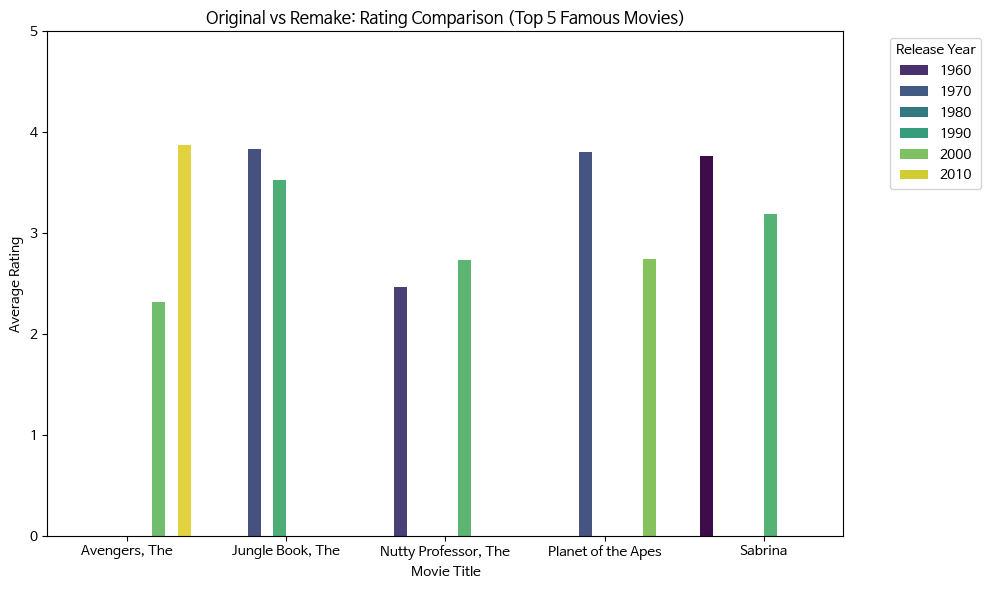


[장르 기반 리메이크 분석 결론]
1. 장르 100% 일치 리메이크 수: 36
2. 장르 변경된 리메이크 수 (유사도 >= 0.5): 108
3. 동명이인 의심 영화 수 (유사도 < 0.3): 65

[분석 상세: 장르 변경 사례 (상위 5개)]
                          Title                                  Genre_1  \
0                  12 Angry Men                                    Drama   
2  20,000 Leagues Under the Sea                  Action|Adventure|Sci-Fi   
3                  3:10 to Yuma  Action|Adventure|Drama|Thriller|Western   
6           Alice in Wonderland               Adventure|Children|Fantasy   
8        Amityville Horror, The            Drama|Horror|Mystery|Thriller   

                                        Genre_2  Similarity_Score  
0                                   Crime|Drama               0.5  
2                        Adventure|Drama|Sci-Fi               0.5  
3                    Action|Crime|Drama|Western               0.5  
6  Adventure|Animation|Children|Fantasy|Musical               0.6  
8                               Horror|Thriller               0.

/tmp/ipython-input-4225909263.py:116: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  remake_comparison = dup_titles.groupby('clean_title').apply(analyze_genre_similarity).reset_index(drop=True)


In [ ]:
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc
import re

# 운영체제별 폰트 설정
system_name = platform.system()

if system_name == 'Windows':
    # 윈도우
    rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    # 맥 (Mac)
    rc('font', family='AppleGothic')
elif system_name == 'Linux':
    # 코랩 / 리눅스 (나눔글꼴 설치 필요)
    rc('font', family='NanumBarunGothic')
else:
    print("Unknown System")

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
movies = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2025-2 빅데이터알고리즘/movies.csv')
ratings = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2025-2 빅데이터알고리즘/ratings.csv')

# 1. 데이터 전처리: 제목과 연도 분리
def extract_year_title(text):
    # 텍스트가 문자열이 아닌 경우 처리
    if not isinstance(text, str):
        return str(text), np.nan

    # 괄호 안의 4자리 숫자 추출 (예: (1995))
    match = re.search(r'^(.*)\s\((\d{4})\)$', text)
    if match:
        title = match.group(1).strip()
        year = int(match.group(2))
        return title, year
    return text, np.nan

# apply로 새로운 컬럼 생성
movies[['clean_title', 'year']] = movies['title'].apply(
    lambda x: pd.Series(extract_year_title(x))
)

# 2. 리메이크 의심작 찾기 (제목은 같고 연도는 다른 것)
# clean_title이 중복되는 데이터 찾기
dup_titles = movies[movies.duplicated(subset=['clean_title'], keep=False)].sort_values(by=['clean_title', 'year'])

print(f"총 영화 수: {len(movies)}")
print(f"제목이 동일한(리메이크/중복) 영화 수: {len(dup_titles)}")
print("\n[리메이크 예시 데이터]")
print(dup_titles[['movieId', 'clean_title', 'year', 'genres']].head(10))

# 3. 원작 vs 리메이크 평점 비교 분석
# 평점 데이터와 결합
movie_ratings = ratings.groupby('movieId')['rating'].agg(['mean', 'count']).reset_index()
remake_analysis = dup_titles.merge(movie_ratings, on='movieId')

# 리뷰가 너무 적은 영화는 제외 (노이즈 제거, 10개 미만)
remake_analysis = remake_analysis[remake_analysis['count'] >= 10]

# 같은 제목끼리 그룹화
remake_groups = remake_analysis.groupby('clean_title').filter(lambda x: len(x) >= 2)

# 시각화를 위해 리뷰 수가 많은 상위 5개 리메이크작 선정
top_remakes = remake_groups.groupby('clean_title')['count'].sum().sort_values(ascending=False).head(5).index
plot_data = remake_groups[remake_groups['clean_title'].isin(top_remakes)]

# 4. 시각화: 원작 vs 리메이크 평점 비교
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='clean_title', y='mean', hue='year', palette='viridis')
plt.title("Original vs Remake: Rating Comparison (Top 5 Famous Movies)")
plt.ylabel("Average Rating")
plt.xlabel("Movie Title")
plt.legend(title="Release Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

# 5. 장르 유사도 정밀 분석 (자카드 유사도 적용)
def analyze_genre_similarity(group):
    # 데이터가 2개 미만이면 비교 불가
    if len(group) < 2:
        return None

    genres = group['genres'].tolist()
    years = group['year'].tolist()

    # 첫 번째 영화와 두 번째 영화 비교
    set1 = set(genres[0].split('|'))
    set2 = set(genres[1].split('|'))

    # 교집합과 합집합 계산
    intersection = set1.intersection(set2)
    union = set1.union(set2)

    # 자카드 유사도 계산 (0~1)
    score = len(intersection) / len(union) if len(union) > 0 else 0

    return pd.Series({
        'Title': group['clean_title'].iloc[0],
        'Year_1': years[0],
        'Year_2': years[1],
        'Genre_1': genres[0],
        'Genre_2': genres[1],
        'Is_Exact_Match': set1 == set2,      # 완전 일치 여부
        'Similarity_Score': round(score, 2)  # 유사도 점수
    })

# 그룹별로 적용하여 분석 프레임 생성
remake_comparison = dup_titles.groupby('clean_title').apply(analyze_genre_similarity).reset_index(drop=True)

# 6. 분석 결과 분류 및 출력

# Case A: 장르 100% 일치 (확실한 리메이크)
exact_remakes = remake_comparison[remake_comparison['Is_Exact_Match'] == True]

# Case B: 장르가 조금 변경됨 (유사도 0.5 이상 1.0 미만)
changed_remakes = remake_comparison[
    (remake_comparison['Similarity_Score'] >= 0.5) &
    (remake_comparison['Is_Exact_Match'] == False)
]

# Case C: 이름만 같고 다른 영화 (유사도 0.3 미만, 동명이인)
different_movies = remake_comparison[remake_comparison['Similarity_Score'] < 0.3]

print("\n[장르 기반 리메이크 분석 결론]")
print(f"1. 장르 100% 일치 리메이크 수: {len(exact_remakes)}")
print(f"2. 장르 변경된 리메이크 수 (유사도 >= 0.5): {len(changed_remakes)}")
print(f"3. 동명이인 의심 영화 수 (유사도 < 0.3): {len(different_movies)}")

print("\n[분석 상세: 장르 변경 사례 (상위 5개)]")
print(changed_remakes[['Title', 'Genre_1', 'Genre_2', 'Similarity_Score']].head())

장르 100% 일치 리메이크 수: 36
-> 나중에 어떻게 쓸지 확인


[전처리 아이디어] 이 데이터를 어떻게 쓸지

"Frozen (2013)"을 본 사람에게 "Frozen (2010)"은 추천하면 안 될 수도 있음 (장르가 다르면)

"Aladdin (1992)"을 본 사람에게 "Aladdin (2019)"를 추천해야 함 (같은 IP)

# EDA ver2: 기존 전처리 방식 정당화

In [4]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,188 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and dire

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats

# 폰트 설정 (한글 깨짐 방지)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

## (6) 리메이크 영화 식별  

/tmp/ipython-input-1736778114.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  remake_pairs['genre_similarity'] = remake_pairs.apply(



[장르 기반 리메이크 분석 결론]
1. 장르 100% 일치 리메이크 수: 45
2. 장르 변경된 리메이크 수 (유사도 >= 0.5): 136
3. 동명이작 의심 영화 수 (유사도 < 0.3): 92

[분석 상세: 장르 100% 일치 사례 (상위 5개)]
                        title_1 year_1                    title_2 year_2  \
1159           12 Chairs (1971)   1971           12 Chairs (1976)   1976   
1087  Christmas Carol, A (1977)   1977  Christmas Carol, A (1999)   1999   
435                Alfie (1966)   1966               Alfie (2004)   2004   
202   All the King's Men (1949)   1949  All the King's Men (2006)   2006   
611        Anna Karenina (1935)   1935       Anna Karenina (1997)   1997   

                  genres_1  
1159      Adventure|Comedy  
1087         Drama|Fantasy  
435   Comedy|Drama|Romance  
202                  Drama  
611          Drama|Romance  


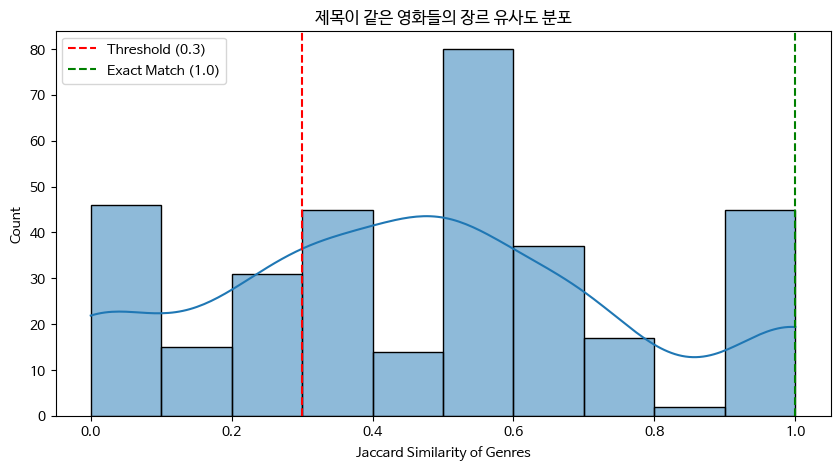

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. 제목 정규화 함수 (The, A 처리 및 특수문자 제거)
def normalize_title(title):
    # 연도 제거
    title = re.sub(r'\s*\(\d{4}\)', '', title)
    # ", The", ", A", ", An" 등을 앞으로 이동 (MovieLens 데이터 특성 처리)
    if title.endswith(', The'):
        title = 'The ' + title[:-5]
    elif title.endswith(', A'):
        title = 'A ' + title[:-3]
    elif title.endswith(', An'):
        title = 'An ' + title[:-4]
    # 소문자 변환 및 특수문자 제거 (알파벳과 숫자만 남김)
    title = re.sub(r'[^a-zA-Z0-9 ]', '', title).lower().strip()
    return title

movies['norm_title'] = movies['title'].apply(normalize_title)
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')

# 2. 같은 제목, 다른 연도의 영화 그룹핑
dup_candidates = movies[movies.duplicated(subset=['norm_title'], keep=False)].copy()

# 3. 장르 자카드 유사도 계산 함수
def calculate_jaccard(genre_str1, genre_str2):
    set1 = set(genre_str1.split('|'))
    set2 = set(genre_str2.split('|'))
    if not set1 or not set2: return 0.0
    return len(set1 & set2) / len(set1 | set2)

# 4. 리메이크 판별 (자기 자신과의 조인)
merged_dups = pd.merge(dup_candidates, dup_candidates, on='norm_title', suffixes=('_1', '_2'))
# 같은 영화(ID 동일)와 연도가 앞선 영화가 뒤에 오는 경우(중복 제거) 제외
remake_pairs = merged_dups[merged_dups['year_1'] < merged_dups['year_2']]

# 장르 유사도 계산
remake_pairs['genre_similarity'] = remake_pairs.apply(
    lambda x: calculate_jaccard(x['genres_1'], x['genres_2']), axis=1
)

# 5. 리메이크 vs 동명이작 분류
exact_remakes = remake_pairs[remake_pairs['genre_similarity'] == 1.0].sort_values('norm_title')
high_sim_remakes = remake_pairs[(remake_pairs['genre_similarity'] >= 0.5) & (remake_pairs['genre_similarity'] < 1.0)]
different_movies = remake_pairs[remake_pairs['genre_similarity'] < 0.3]

# 결과 출력
print("\n[장르 기반 리메이크 분석 결론]")
print(f"1. 장르 100% 일치 리메이크 수: {len(exact_remakes)}")
print(f"2. 장르 변경된 리메이크 수 (유사도 >= 0.5): {len(high_sim_remakes)}")
print(f"3. 동명이작 의심 영화 수 (유사도 < 0.3): {len(different_movies)}")

# 확인용 출력 (100% 일치 사례)
print("\n[분석 상세: 장르 100% 일치 사례 (상위 5개)]")
print(exact_remakes[['title_1', 'year_1', 'title_2', 'year_2', 'genres_1']].head())

# 시각화
plt.figure(figsize=(10, 5))
sns.histplot(remake_pairs['genre_similarity'], bins=10, kde=True)
plt.axvline(0.3, color='red', linestyle='--', label='Threshold (0.3)')
plt.axvline(1.0, color='green', linestyle='--', label='Exact Match (1.0)')
plt.title('제목이 같은 영화들의 장르 유사도 분포')
plt.xlabel('Jaccard Similarity of Genres')
plt.legend()
plt.show()

- 연도 제거 + 관사 처리 + 소문자 변환 + 특수문자 제거  
- 일부 100% 리메이크 영화 검색 결과 movielens 데이터상 오류가 의심됨  
(ex. 12개의 의자, 1970년 개봉 -> 1976년과는 무관)  
- 일일이 검색해서 식별이 최선일까..?

### 심화 검증 지표 추가  
1. 태그 유사도: TF-IDF 벡터 간의 cosine similarity
2. 사용자 패턴  
- Co-Raters (공통 평가자 수): 두 영화를 모두 본 사람의 수
- Rating Correlation (평점 상관관계): 공통 평가자들이 준 점수의 경향성 비교 (ex. 원작을 좋게 본 사람이 리메이크도 좋게 봤는지
- 필터링 조건  
1) 장르가 100% 같거나  
2) 장르가 비슷하면서(>0.5) 태그 유사도가 있거나(>0.1)  
3) 장르가 조금 달라도(>0.3) 공통 사용자가 꽤 있고 상관관계가 양수일 때


In [7]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr


# 1. 기본 전처리 & 후보군 선정
def normalize_title(title):
    title = re.sub(r'\s*\(\d{4}\)', '', str(title))
    if title.endswith(', The'): title = 'The ' + title[:-5]
    elif title.endswith(', A'): title = 'A ' + title[:-3]
    title = re.sub(r'[^a-zA-Z0-9 ]', '', title).lower().strip()
    return title

movies['norm_title'] = movies['title'].apply(normalize_title)
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)

# 후보군 추출 (제목이 같고 연도가 다른 쌍)
dup_candidates = movies[movies.duplicated(subset=['norm_title'], keep=False)].copy()
remake_pairs = pd.merge(dup_candidates, dup_candidates, on='norm_title', suffixes=('_1', '_2'))
remake_pairs = remake_pairs[remake_pairs['year_1'] < remake_pairs['year_2']].reset_index(drop=True)

# 장르 유사도 (Jaccard)
def get_genre_sim(g1, g2):
    s1, s2 = set(g1.split('|')), set(g2.split('|'))
    return len(s1 & s2) / len(s1 | s2) if s1 or s2 else 0

remake_pairs['genre_sim'] = remake_pairs.apply(lambda x: get_genre_sim(x['genres_1'], x['genres_2']), axis=1)


# 2. 태그 기반 내용 유사도 (Content-based Filtering)
print("태그 유사도 계산 중...")
# 영화별 태그 합치기 (결측치 처리)
tags['tag'] = tags['tag'].astype(str).fillna('')
movie_tags = tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x)).reset_index()

# TF-IDF 벡터화
tfidf = TfidfVectorizer(stop_words='english')
# 전체 영화에 대해 피팅하지 않고, 후보군에 있는 태그만 사용해도 됨
# 여기서는 후보군에 태그 정보를 매핑
tag_map = movie_tags.set_index('movieId')['tag']

def calculate_tag_similarity(row):
    tag1 = tag_map.get(row['movieId_1'], "")
    tag2 = tag_map.get(row['movieId_2'], "")

    # 둘 중 하나라도 태그가 없으면 비교 불가 (0 처리)
    if not tag1 or not tag2:
        return 0.0

    # 코사인 유사도 계산
    tfidf_matrix = tfidf.fit_transform([tag1, tag2])
    return cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

remake_pairs['tag_sim'] = remake_pairs.apply(calculate_tag_similarity, axis=1)


# 3. 사용자 평가 패턴 분석 (Collaborative Filtering)
print("사용자 패턴 분석 중...")

# 평점 데이터를 딕셔너리 형태로 변환 (속도 최적화)
# key: movieId, value: {userId: rating, ...}
rating_dict = ratings.groupby('movieId').apply(lambda x: dict(zip(x.userId, x.rating))).to_dict()

def analyze_user_behavior(row):
    # 각 영화를 본 유저 목록 및 평점 가져오기
    dict1 = rating_dict.get(row['movieId_1'], {})
    dict2 = rating_dict.get(row['movieId_2'], {})

    users1 = set(dict1.keys())
    users2 = set(dict2.keys())

    # 1. 공통 사용자 수 (Co-raters)
    common_users = users1 & users2
    num_common = len(common_users)

    # 2. 사용자 자카드 유사도 (User Overlap Ratio)
    # 두 영화의 관객층이 얼마나 겹치는지
    user_jaccard = num_common / len(users1 | users2) if (users1 or users2) else 0

    # 3. 평점 상관관계 (Rating Correlation)
    # 공통 사용자가 적으면(예: 5명 미만) 상관관계 신뢰도가 낮음
    corr = np.nan
    if num_common >= 5:
        ratings1 = [dict1[u] for u in common_users]
        ratings2 = [dict2[u] for u in common_users]
        # 피어슨 상관계수 (범위: -1 ~ 1)
        # 상관계수가 계산되지 않는 경우(분산 0) 대비
        try:
            corr, _ = pearsonr(ratings1, ratings2)
        except:
            corr = 0

    return pd.Series([num_common, user_jaccard, corr])

remake_pairs[['num_common_users', 'user_overlap', 'rating_corr']] = remake_pairs.apply(analyze_user_behavior, axis=1)


# 4. 종합 필터링 및 결과 확인

# 필터링 조건
# 1. 장르가 100% 같거나
# 2. 장르가 비슷하면서(>0.5) 태그 유사도가 있거나(>0.1)
# 3. 장르가 조금 달라도(>0.3) 공통 사용자가 꽤 있고 상관관계가 양수일 때
final_remakes = remake_pairs[
    (remake_pairs['genre_sim'] == 1.0) |
    ((remake_pairs['genre_sim'] >= 0.5) & (remake_pairs['tag_sim'] > 0.1)) |
    ((remake_pairs['genre_sim'] >= 0.3) & (remake_pairs['rating_corr'] > 0.3))
].sort_values('genre_sim', ascending=False)

# 의심 사례 (동명이작 가능성 높음)
suspicious = remake_pairs[
    (remake_pairs['genre_sim'] < 0.3) &
    (remake_pairs['tag_sim'] == 0) &
    (remake_pairs['num_common_users'] < 5)
]

print(f"\n[분석 결과]")
print(f"검토 대상 전체 쌍: {len(remake_pairs)}")
print(f"최종 리메이크/시리즈 판단: {len(final_remakes)}")
print(f"동명이작(다른 영화) 의심: {len(suspicious)}")

print("\n[최종 리메이크 판단 샘플 (Top 5)]")
display_cols = ['title_1', 'year_1', 'title_2', 'year_2', 'genre_sim', 'tag_sim', 'rating_corr']
print(final_remakes[display_cols].head())

print("\n[동명이작 의심 샘플 (Bottom 5)]")
print(suspicious[display_cols].head())

태그 유사도 계산 중...
사용자 패턴 분석 중...

[분석 결과]
검토 대상 전체 쌍: 332
최종 리메이크/시리즈 판단: 55
동명이작(다른 영화) 의심: 89

[최종 리메이크 판단 샘플 (Top 5)]
                       title_1  year_1                     title_2  year_2  \
0            Persuasion (1995)  1995.0           Persuasion (2007)  2007.0   
17            Jane Eyre (1996)  1996.0            Jane Eyre (2011)  2011.0   
20                 Emma (1996)  1996.0                 Emma (2009)  2009.0   
22              Sabrina (1954)  1954.0              Sabrina (1995)  1995.0   
26  Father of the Bride (1950)  1950.0  Father of the Bride (1991)  1991.0   

    genre_sim   tag_sim  rating_corr  
0         1.0  0.000000          NaN  
17        1.0  0.000000          NaN  
20        1.0  0.000000          NaN  
22        1.0  0.000000     0.037582  
26        1.0  0.579739          NaN  

[동명이작 의심 샘플 (Bottom 5)]
                    title_1  year_1                 title_2  year_2  \
2    Misérables, Les (1995)  1995.0  Misérables, Les (2012)  2012.0   
5    Man of 

/tmp/ipython-input-1522930407.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rating_dict = ratings.groupby('movieId').apply(lambda x: dict(zip(x.userId, x.rating))).to_dict()


- 제목은 같지만 개봉 연도가 다른 영화: 332개  
- 리메이크/시리즈 판단: 55개  
- 동명이작 의심: 89개 (제목만 같을 뿐 장르, 태그, 평점 패턴에서 연관성이 낮아 서로 다른 영화로 판단)

## (7) 사용자별 편향 및 분산 파악

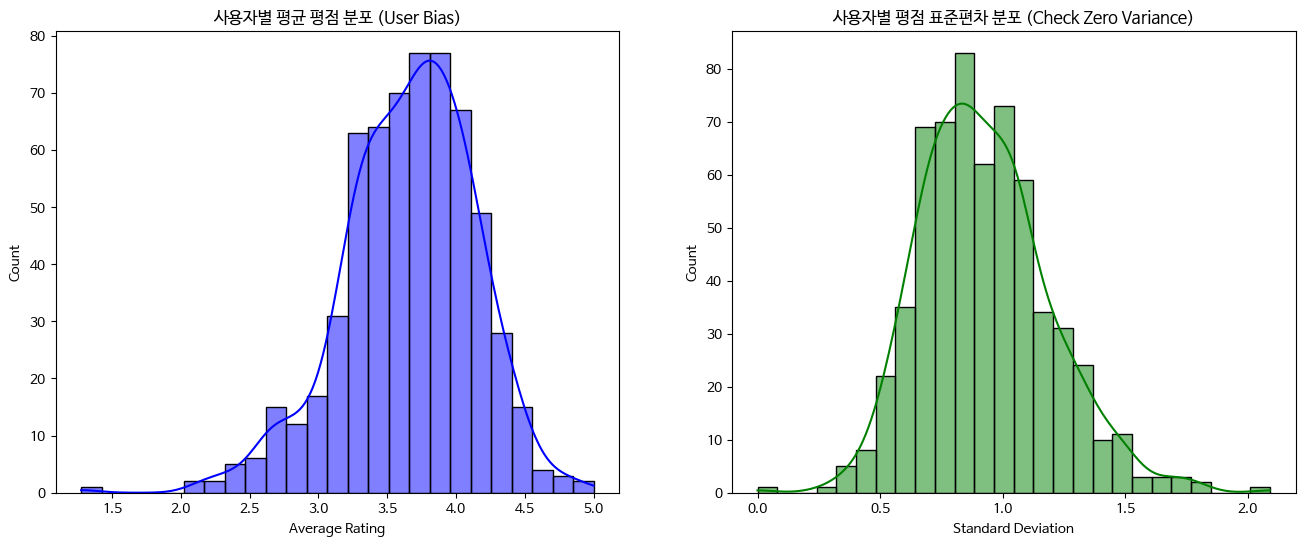

평점 분산이 0인(모든 영화에 같은 점수를 준) 사용자 수: 1


In [6]:
# 데이터 병합
df = pd.merge(ratings, movies, on='movieId')

# User/Item 평균 평점 및 분산 분포
user_stats = df.groupby('userId')['rating'].agg(['mean', 'std', 'count'])
item_stats = df.groupby('movieId')['rating'].agg(['mean', 'std', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 사용자별 평균 평점 분포 (Bias 확인)
sns.histplot(user_stats['mean'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('사용자별 평균 평점 분포 (User Bias)')
axes[0].set_xlabel('Average Rating')

# 사용자별 평점 표준편차 분포 (Zero Variance 확인)
sns.histplot(user_stats['std'].dropna(), kde=True, ax=axes[1], color='green')
axes[1].set_title('사용자별 평점 표준편차 분포 (Check Zero Variance)')
axes[1].set_xlabel('Standard Deviation')
plt.show()

# 제로 분산 사용자 확인 (표준편차 0인 사용자 수)
zero_var_users = user_stats[user_stats['std'] == 0]
print(f"평점 분산이 0인(모든 영화에 같은 점수를 준) 사용자 수: {len(zero_var_users)}")

- 사용자별 평균 평점 분포: 사용자의 평균 평점이 대체로 3.5에서 4.0 사이에 집중되어 있음 -> 이는 많은 사용자가 영화에 대해 긍정적인 평가를 내리는 경향이 있음을 보여주며, 일부 사용자는 평균 평점이 매우 낮거나 높은 사용자 편향이 존재함을 시사
- 사용자별 평점 표준편차 분포: 표준편차가 0.5에서 1.0 사이에 많이 분포 -> 이는 대부분의 사용자가 평점을 줄 때 일정한 변동성을 가지고 있음을 의미함. 하지만 표준편차가 0에 가까운 사용자들도 있어, 이들은 모든 영화에 같은 점수를 주는 Zero Variance 사용자일 가능성이 높음. 이런 사용자들은 정보량이 없어 제외하거나 별도 처리가 필요

## (8) 희소성(Sparsity) 및 Long-Tail 분포 (IUF 정당화)

전체 사용자 수: 610, 전체 아이템 수: 9724
Matrix Sparsity: 0.9830


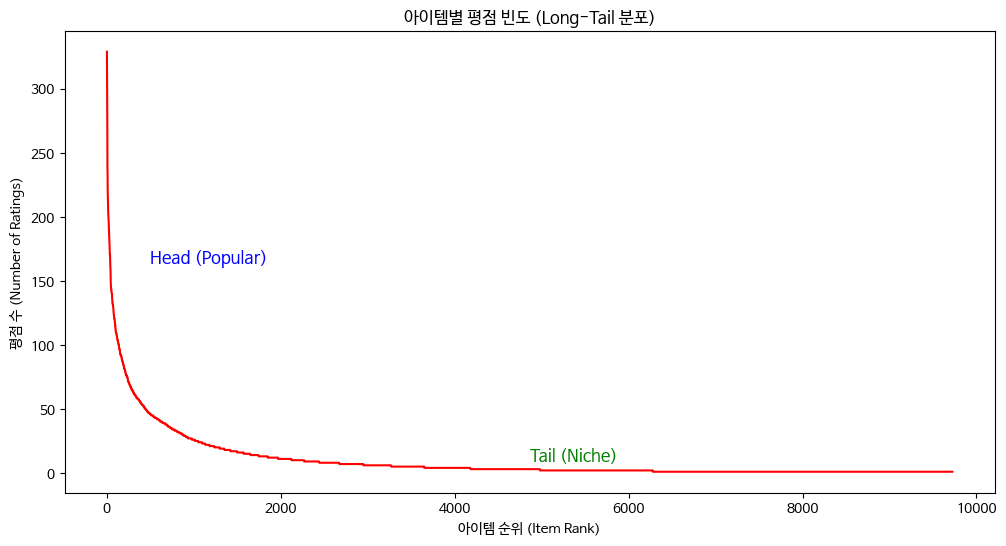

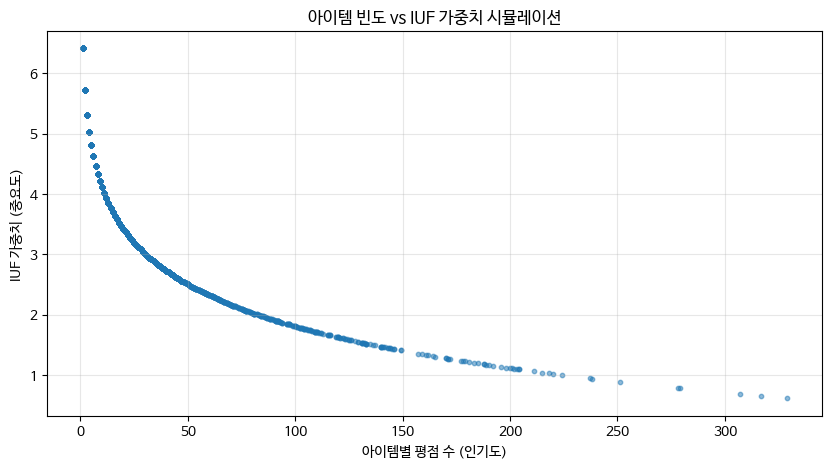

In [10]:
# User-Item 상호작용 희소성 및 롱테일 분포
num_users = df['userId'].nunique()
num_items = df['movieId'].nunique()
sparsity = 1 - (len(df) / (num_users * num_items))

print(f"전체 사용자 수: {num_users}, 전체 아이템 수: {num_items}")
print(f"Matrix Sparsity: {sparsity:.4f}")

# Long-Tail Plot (IUF 필요성 증명)
# 인기가 너무 많은 소수의 영화가 전체 평점의 대부분을 차지하는지 확인
item_counts = df['movieId'].value_counts()

plt.figure(figsize=(12, 6))
plt.plot(item_counts.values, color='red')
plt.title('아이템별 평점 빈도 (Long-Tail 분포)')
plt.xlabel('아이템 순위 (Item Rank)')
plt.ylabel('평점 수 (Number of Ratings)')
plt.text(500, item_counts.values[0]/2, 'Head (Popular)', fontsize=12, color='blue')
plt.text(len(item_counts)/2, 10, 'Tail (Niche)', fontsize=12, color='green')
plt.show()

# IUF (Inverse User Frequency) 가중치 시뮬레이션
# 많이 평가된 아이템일수록 가중치가 낮아지는 형태 시각화
IUF = np.log(num_users / item_counts)
plt.figure(figsize=(10, 5))
plt.scatter(item_counts, IUF, alpha=0.5, s=10)
plt.title('아이템 빈도 vs IUF 가중치 시뮬레이션')
plt.xlabel('아이템별 평점 수 (인기도)')
plt.ylabel('IUF 가중치 (중요도)')
plt.grid(True, alpha=0.3)
plt.show()

- 소수의 인기 아이템(Head)이 전체 평점의 대부분을 차지하고, 대다수의 아이템(Tail)은 평점 수가 매우 적은 지수 함수적 감소 형태(Long tail)를 보임  
- 인기 영화만 추천되는 편향이 발생할 가능성이 매우 높음  
- 너무 흔한 아이템의 영향력을 낮추고 꼬리 부분(Niche)의 숨겨진 명작을 발굴할 수 있도록 IUF (Inverse User Frequency) 같은 가중치를 적용하는 전처리를 정당화

## (9) 사용자 평가 성향 정규화 비교 (Mean Centering vs Z-score)

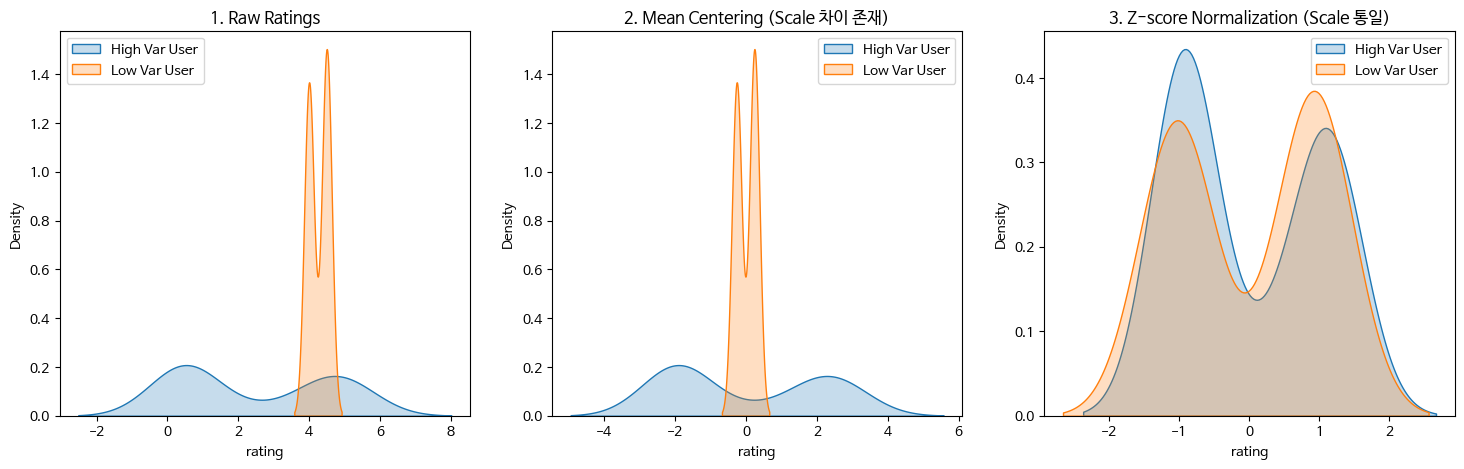

In [7]:
# Z-score Normalization의 필요성 시각화
# 분산이 큰 유저와 작은 유저 비교
# std가 높은 상위 10% 유저와 하위 10% 유저 추출
high_var_user = user_stats[user_stats['count'] > 20].sort_values('std', ascending=False).index[0]
low_var_user = user_stats[user_stats['count'] > 20].sort_values('std', ascending=True).index[0]

user_h_ratings = df[df['userId'] == high_var_user]['rating']
user_l_ratings = df[df['userId'] == low_var_user]['rating']

# 정규화 계산
def z_score(series):
    return (series - series.mean()) / series.std()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw Ratings
sns.kdeplot(user_h_ratings, label='High Var User', ax=axes[0], fill=True)
sns.kdeplot(user_l_ratings, label='Low Var User', ax=axes[0], fill=True)
axes[0].set_title('1. Raw Ratings')

# Mean Centering (평균만 뺌)
sns.kdeplot(user_h_ratings - user_h_ratings.mean(), label='High Var User', ax=axes[1], fill=True)
sns.kdeplot(user_l_ratings - user_l_ratings.mean(), label='Low Var User', ax=axes[1], fill=True)
axes[1].set_title('2. Mean Centering (Scale 차이 존재)')

# Z-score Normalization (평균 빼고 표준편차 나눔)
sns.kdeplot(z_score(user_h_ratings), label='High Var User', ax=axes[2], fill=True)
sns.kdeplot(z_score(user_l_ratings), label='Low Var User', ax=axes[2], fill=True)
axes[2].set_title('3. Z-score Normalization (Scale 통일)')

for ax in axes: ax.legend()
plt.show()

1. Raw Ratings: 어떤 유저는 4~5점만 주고(후함), 어떤 유저는 1~3점을 주로 줌(까다로움)  
2. Mean Centering: 평균을 0으로 맞춰도 분산(퍼짐 정도) 차이 존재
3. Z-score: 평균 0, 표준편차 1로 통일되어 두 유저의 점수 분포가 거의 겹쳐짐
-> 사용자마다 평점 기준이 다르므로(Bias & Variance), Z-score Normalization을 통해 개인별 성향을 제거하고 상대적인 선호도만 남겨야 아이템 간 공정한 비교가 가능

## (10) 유사도 신뢰도 가중치 (Significance Weighting) 정당화

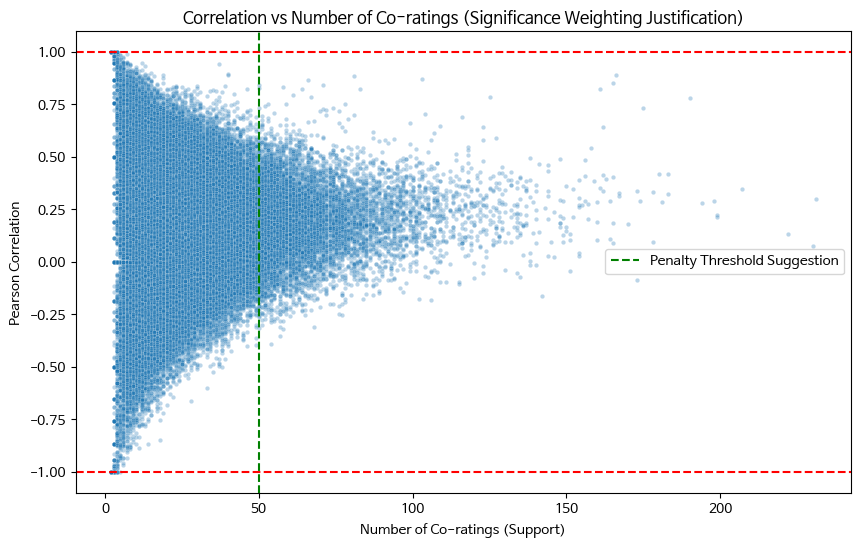

관찰: 공통 평가 수(Support)가 적을수록 상관계수가 극단적(1.0 or -1.0)으로 나타남. 이는 신뢰도가 낮음을 의미.


In [8]:
# Significance Weighting 필요성 시각화
# 피벗 테이블 생성 (메모리 문제 시 일부 데이터만 샘플링)
sample_movies = df['movieId'].value_counts().head(500).index  # 상위 500개 영화만
pivot_sample = df[df['movieId'].isin(sample_movies)].pivot_table(index='userId', columns='movieId', values='rating')

# 영화 간 상관관계 계산 (Pearson) 및 공통 평가 수 계산
corr_matrix = pivot_sample.corr(method='pearson', min_periods=1)

# 상관계수와 공통 평가 수(Support) 관계 추출
# 매트릭스의 상삼각행렬만 추출하여 중복 제거
corr_data = []
movie_ids = pivot_sample.columns
for i in range(len(movie_ids)):
    for j in range(i+1, len(movie_ids)):
        m1, m2 = movie_ids[i], movie_ids[j]
        # 공통 평가 수 계산
        common_support = pivot_sample[[m1, m2]].dropna().shape[0]
        correlation = corr_matrix.loc[m1, m2]
        if not np.isnan(correlation):
            corr_data.append({'support': common_support, 'correlation': correlation})

corr_df = pd.DataFrame(corr_data)

# 시각화: Support vs Correlation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=corr_df, x='support', y='correlation', alpha=0.3, s=10)
plt.axhline(1.0, color='r', linestyle='--')
plt.axhline(-1.0, color='r', linestyle='--')
plt.axvline(50, color='green', linestyle='--', label='Penalty Threshold Suggestion') # 예: 50개 미만은 패널티
plt.title('Correlation vs Number of Co-ratings (Significance Weighting Justification)')
plt.xlabel('Number of Co-ratings (Support)')
plt.ylabel('Pearson Correlation')
plt.legend()
plt.show()

print("관찰: 공통 평가 수(Support)가 적을수록 상관계수가 극단적(1.0 or -1.0)으로 나타남. 이는 신뢰도가 낮음을 의미.")

- 공통 평가자 수(Support)가 50명 미만인 왼쪽 영역에서 피어슨 상관계수가 -1.0부터 1.0까지 극단적으로 흩어져 있음 -> 소수의 사람만 공통으로 평가한 경우, 우연에 의해 상관계수가 과대/과소평가될 위험이 큼  
- 반면, Support가 증가할수록(오른쪽으로 갈수록) 상관계수는 0.0~0.5 사이로 수렴하며 안정적인 분포를 보임
- 공통 평가 수가 적은 경우(예: 50명 미만) 유사도 점수에 페널티를 주어 추천의 신뢰성을 높이는 Significance Weighting(신뢰도 가중치) 전처리를 정당화


# EDA ver3

## (11) Cold Start 유저/아이템 필터링 기준 설정

너무 적은 데이터를 가진 유저나 아이템을 제거하기 위한 기준점을 찾기

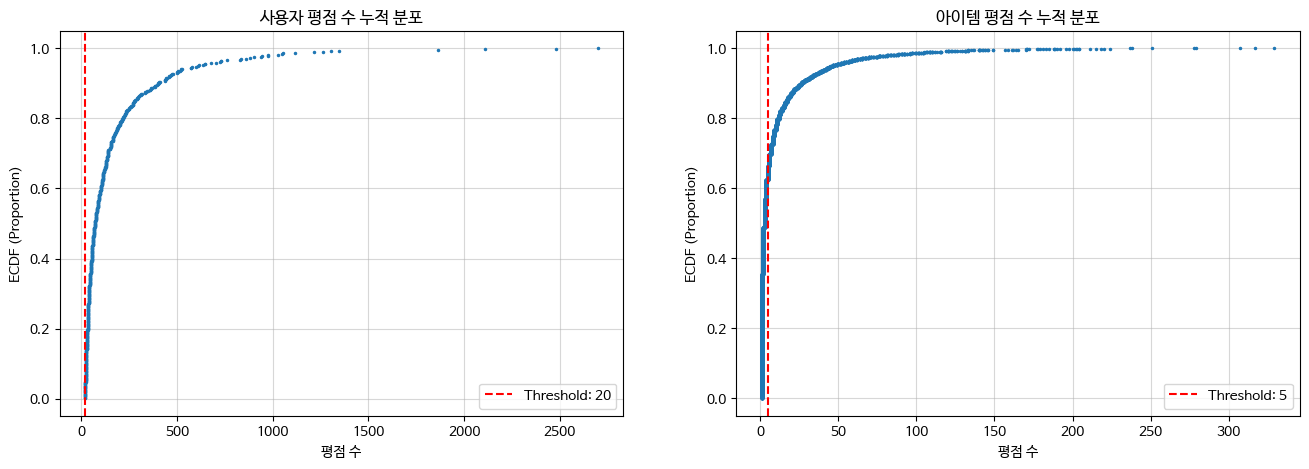

In [12]:
# 1. 데이터 다시 집계
df = pd.merge(ratings, movies, on='movieId')
# count(평가 수)를 포함하여 다시 집계
user_stats = df.groupby('userId')['rating'].agg(['mean', 'std', 'count']).reset_index()
item_stats = df.groupby('movieId')['rating'].agg(['mean', 'std', 'count']).reset_index()

# 2. ECDF 그리기
def plot_ecdf(data, title, xlabel):
    x = np.sort(data)
    y = np.arange(1, len(data) + 1) / len(data)
    plt.plot(x, y, marker='.', linestyle='none', markersize=3)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('ECDF (Proportion)')
    plt.grid(True, which="both", ls="-", alpha=0.5)

plt.figure(figsize=(16, 5))

# 유저별 평가 수 분포
plt.subplot(1, 2, 1)
plot_ecdf(user_stats['count'], '사용자 평점 수 누적 분포', '평점 수')
plt.axvline(20, color='r', linestyle='--', label='Threshold: 20')
plt.legend()

# 아이템별 평가 수 분포
plt.subplot(1, 2, 2)
plot_ecdf(item_stats['count'], '아이템 평점 수 누적 분포', '평점 수')
plt.axvline(5, color='r', linestyle='--', label='Threshold: 5')
plt.legend()

plt.show()

- User: 약 20%의 사용자만이 100개 이상의 평점을 남겼고, 대다수는 20개 미만  
- Item: 상위 10%의 영화가 대부분의 평점을 가져가고, 나머지는 평가 수가 5개 미만인 경우가 많음  
- Cold Start 문제를 해결하기 위해, 평가 수가 너무 적은 유저나 아이템(Threshold 미만)은 학습 데이터에서 제외하거나 별도의 처리를 해야 추천 모델의 안정성을 확보 가능

## (12) 장르별 평점 시계열 트렌드

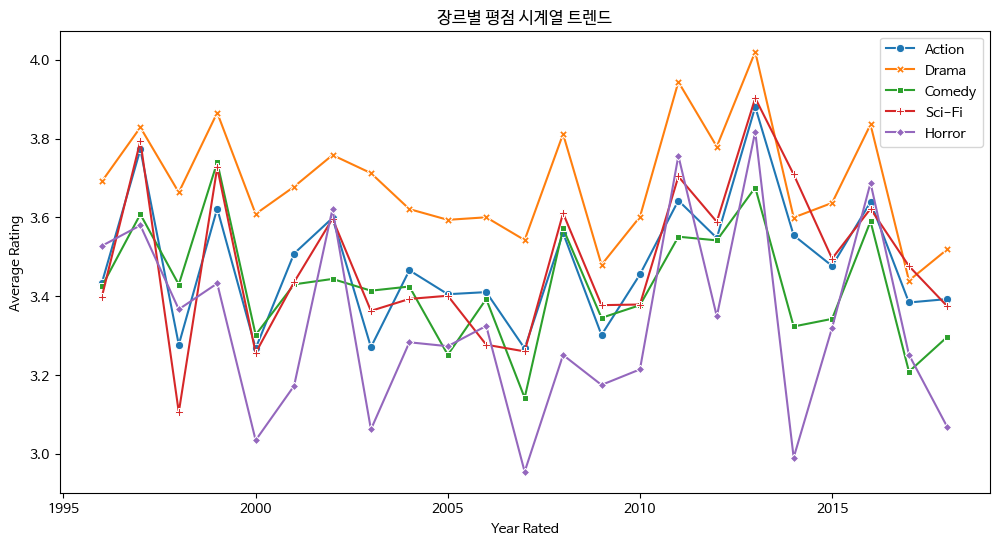

In [15]:
# 장르 One-Hot Encoding 활용
genre_dummies = movies['genres'].str.get_dummies(sep='|')
df_genre = pd.concat([df, genre_dummies.reindex(df.index)], axis=1)

# 연도별 장르 평균 평점
# 'timestamp'를 연도로 변환
df['year_rated'] = pd.to_datetime(df['timestamp'], unit='s').dt.year

# 주요 장르 몇 개만 선택하여 추이 확인
target_genres = ['Action', 'Drama', 'Comedy', 'Sci-Fi', 'Horror']
genre_trend = []

for genre in target_genres:
    # 해당 장르인 영화들의 연도별 평점 평균
    # (여기서는 '개봉연도'가 아닌 '평가 시점' 기준 트렌드 예시)
    # 개봉연도 기준을 원하면 movies['year']으로 수정 후 실행
    genre_rows = df[df['movieId'].isin(movies[movies['genres'].str.contains(genre)]['movieId'])]
    yearly_mean = genre_rows.groupby('year_rated')['rating'].mean()
    yearly_mean.name = genre
    genre_trend.append(yearly_mean)

trend_df = pd.concat(genre_trend, axis=1)

plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_df, dashes=False, markers=True)
plt.title('장르별 평점 시계열 트렌드')
plt.ylabel('Average Rating')
plt.xlabel('Year Rated')
plt.show()

- 연도별로 장르 평균 평점이 등락을 거듭하며, 특정 시기(예: 2000년대 후반)에는 전반적으로 낮아지거나 높아지는 경향이 보임 -> 특히 'Horror' 장르는 다른 장르에 비해 평점이 낮은 경향이 있음  
- 영화의 개봉 시기의 트렌드나 장르적 특성이 평점에 영향을 미치므로, 이를 보정하거나 모델링 시 피처로 활용해야 함